## Important Libirary

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler,OrdinalEncoder

## Read Data

In [32]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\deeplearning project\train.csv")
df_test = pd.read_csv(r"C:\Users\Admin\Downloads\deeplearning project\test.csv")
df

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,Clay,6.54,13.45,1.15,1.86,26.65,26.86,1041.33,10.62,...,Rice,Sowing,Kharif,Sprinkler,River,4.35,No,118.36,South,Medium
629996,629996,Clay,7.03,54.49,0.96,2.35,36.99,88.00,1419.57,9.93,...,Sugarcane,Vegetative,Kharif,Drip,Groundwater,12.97,Yes,40.75,Central,Medium
629997,629997,Clay,6.52,11.98,0.93,0.38,37.82,70.98,88.45,8.19,...,Potato,Vegetative,Zaid,Canal,Reservoir,13.58,Yes,2.62,South,High
629998,629998,Clay,5.93,42.86,0.33,3.39,34.99,94.58,2433.92,9.88,...,Sugarcane,Vegetative,Zaid,Sprinkler,Groundwater,0.79,Yes,90.00,East,Low


In [33]:
df.info() # train data info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [34]:
df_test.info() # test data info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Soil_Type                270000 non-null  object 
 2   Soil_pH                  270000 non-null  float64
 3   Soil_Moisture            270000 non-null  float64
 4   Organic_Carbon           270000 non-null  float64
 5   Electrical_Conductivity  270000 non-null  float64
 6   Temperature_C            270000 non-null  float64
 7   Humidity                 270000 non-null  float64
 8   Rainfall_mm              270000 non-null  float64
 9   Sunlight_Hours           270000 non-null  float64
 10  Wind_Speed_kmh           270000 non-null  float64
 11  Crop_Type                270000 non-null  object 
 12  Crop_Growth_Stage        270000 non-null  object 
 13  Season                   270000 non-null  object 
 14  Irri

In [35]:
df.describe().T # describe train data

,count,mean,std,min,25%,50%,75%,max
id,630000.0,314999.500000,181865.479132,0.00,157499.7500,314999.50,472499.25,629999.00
Soil_pH,630000.0,6.482497,0.922504,4.80,5.6900,6.44,7.27,8.20
Soil_Moisture,630000.0,37.304482,16.377082,8.00,23.3400,37.75,51.27,64.99
Organic_Carbon,630000.0,0.922858,0.365808,0.30,0.6100,0.91,1.22,1.60
Electrical_Conductivity,630000.0,1.744605,0.952321,0.10,0.9300,1.74,2.58,3.50
Temperature_C,630000.0,26.998166,8.623621,12.00,19.5175,26.96,34.54,42.00
Humidity,630000.0,61.563180,19.708152,25.00,45.3900,61.65,79.12,94.99
Rainfall_mm,630000.0,1462.207566,612.989738,0.38,954.5700,1467.16,2054.28,2499.69
Sunlight_Hours,630000.0,7.513382,1.999322,4.00,5.7600,7.58,9.25,11.00
Wind_Speed_kmh,630000.0,10.375394,5.689458,0.50,5.2800,10.48,15.43,20.00


In [36]:
df.describe(include='object').T # describe object in train data

,count,unique,top,freq
Soil_Type,630000,4,Sandy,166509
Crop_Type,630000,6,Sugarcane,108910
Crop_Growth_Stage,630000,4,Harvest,167689
Season,630000,3,Kharif,216561
Irrigation_Type,630000,4,Canal,161901
Water_Source,630000,4,Reservoir,162994
Mulching_Used,630000,2,No,316453
Region,630000,5,South,134809
Irrigation_Need,630000,3,Low,369917


In [37]:
df.duplicated().sum() # check duplicate

np.int64(0)

In [38]:
df.isnull().sum() # check nulls

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

<Axes: xlabel='Irrigation_Need', ylabel='count'>

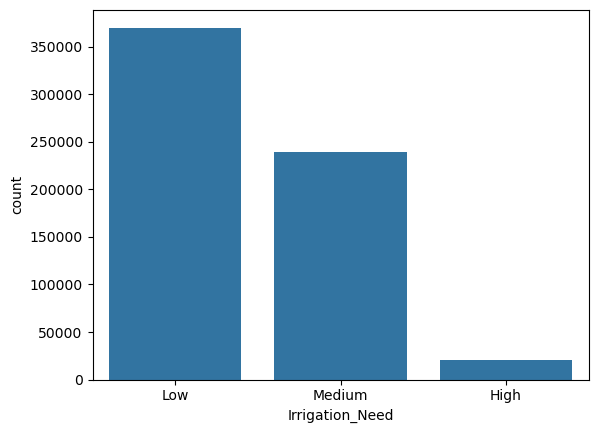

In [39]:
sns.countplot(x='Irrigation_Need',data=df) # target colunm dustribution

In [ ]:
# encoding Target column
mapping = {'Low': 0, 'Medium': 1, 'High':2}
df['Irrigation_Need'] = df['Irrigation_Need'].map(mapping).astype(int)

## Feature Engineering

In [ ]:
#Temperature × Wind evaporation load proxy
df['evaporative_pressure'] = df['Temperature_C'] * df['Wind_Speed_kmh']
df_test['evaporative_pressure'] = df_test['Temperature_C'] * df_test['Wind_Speed_kmh']

In [42]:
#Demand relative to currently stored soil water
df['dryness_vs_moisture'] = df['evaporative_pressure'] / (df['Soil_Moisture'] + 1e-5)
df_test['dryness_vs_moisture'] = df_test['evaporative_pressure'] / (df_test['Soil_Moisture'] + 1e-5)

In [43]:
#Demand relative to recent rainfall support
df['dryness_vs_rain'] = df['evaporative_pressure'] / (df['Rainfall_mm'] + 1e-5)
df_test['dryness_vs_rain'] = df_test['evaporative_pressure'] / (df_test['Rainfall_mm'] + 1e-5)

In [44]:
# Combined soil, rainfall, and previous irrigation signal
df['available_water_proxy'] = (
    df['Soil_Moisture'] + df['Rainfall_mm'] + df['Previous_Irrigation_mm']
)
df_test['available_water_proxy'] = (
    df_test['Soil_Moisture'] + df_test['Rainfall_mm'] + df_test['Previous_Irrigation_mm']
)

In [45]:
# Moisture modulated by organic-carbon support
df['soil_health_moisture'] = df['Soil_Moisture'] * df['Organic_Carbon']
df_test['soil_health_moisture'] = df_test['Soil_Moisture'] * df_test['Organic_Carbon']

In [46]:
# Moisture discounted by conductivity burden
df['salt_adjusted_moisture'] = df['Soil_Moisture'] / (df['Electrical_Conductivity'] + 1e-5)
df_test['salt_adjusted_moisture'] = df_test['Soil_Moisture'] / (df_test['Electrical_Conductivity'] + 1e-5)

In [47]:
#Temperature and sunlight exposure proxy
df['heat_light_load'] = df['Temperature_C'] * df['Sunlight_Hours']
df_test['heat_light_load'] = df_test['Temperature_C'] * df_test['Sunlight_Hours']

In [48]:
df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Previous_Irrigation_mm,Region,Irrigation_Need,evaporative_pressure,dryness_vs_moisture,dryness_vs_rain,available_water_proxy,soil_health_moisture,salt_adjusted_moisture,heat_light_load
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,112.16,East,0,252.0179,7.735354,0.347137,870.73,32.9058,10.681932,88.5590
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,47.16,South,0,77.6988,1.372528,0.078829,1089.43,24.9084,28.304858,159.9816
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,110.38,North,0,103.8345,3.747184,0.047161,2339.79,22.4451,9.791485,163.1685
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,53.85,South,1,30.7692,2.309998,0.022669,1424.50,17.7156,15.310169,121.4784
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,93.19,South,0,281.8668,4.766093,0.183245,1690.53,22.4732,61.603525,140.5290


<Axes: >

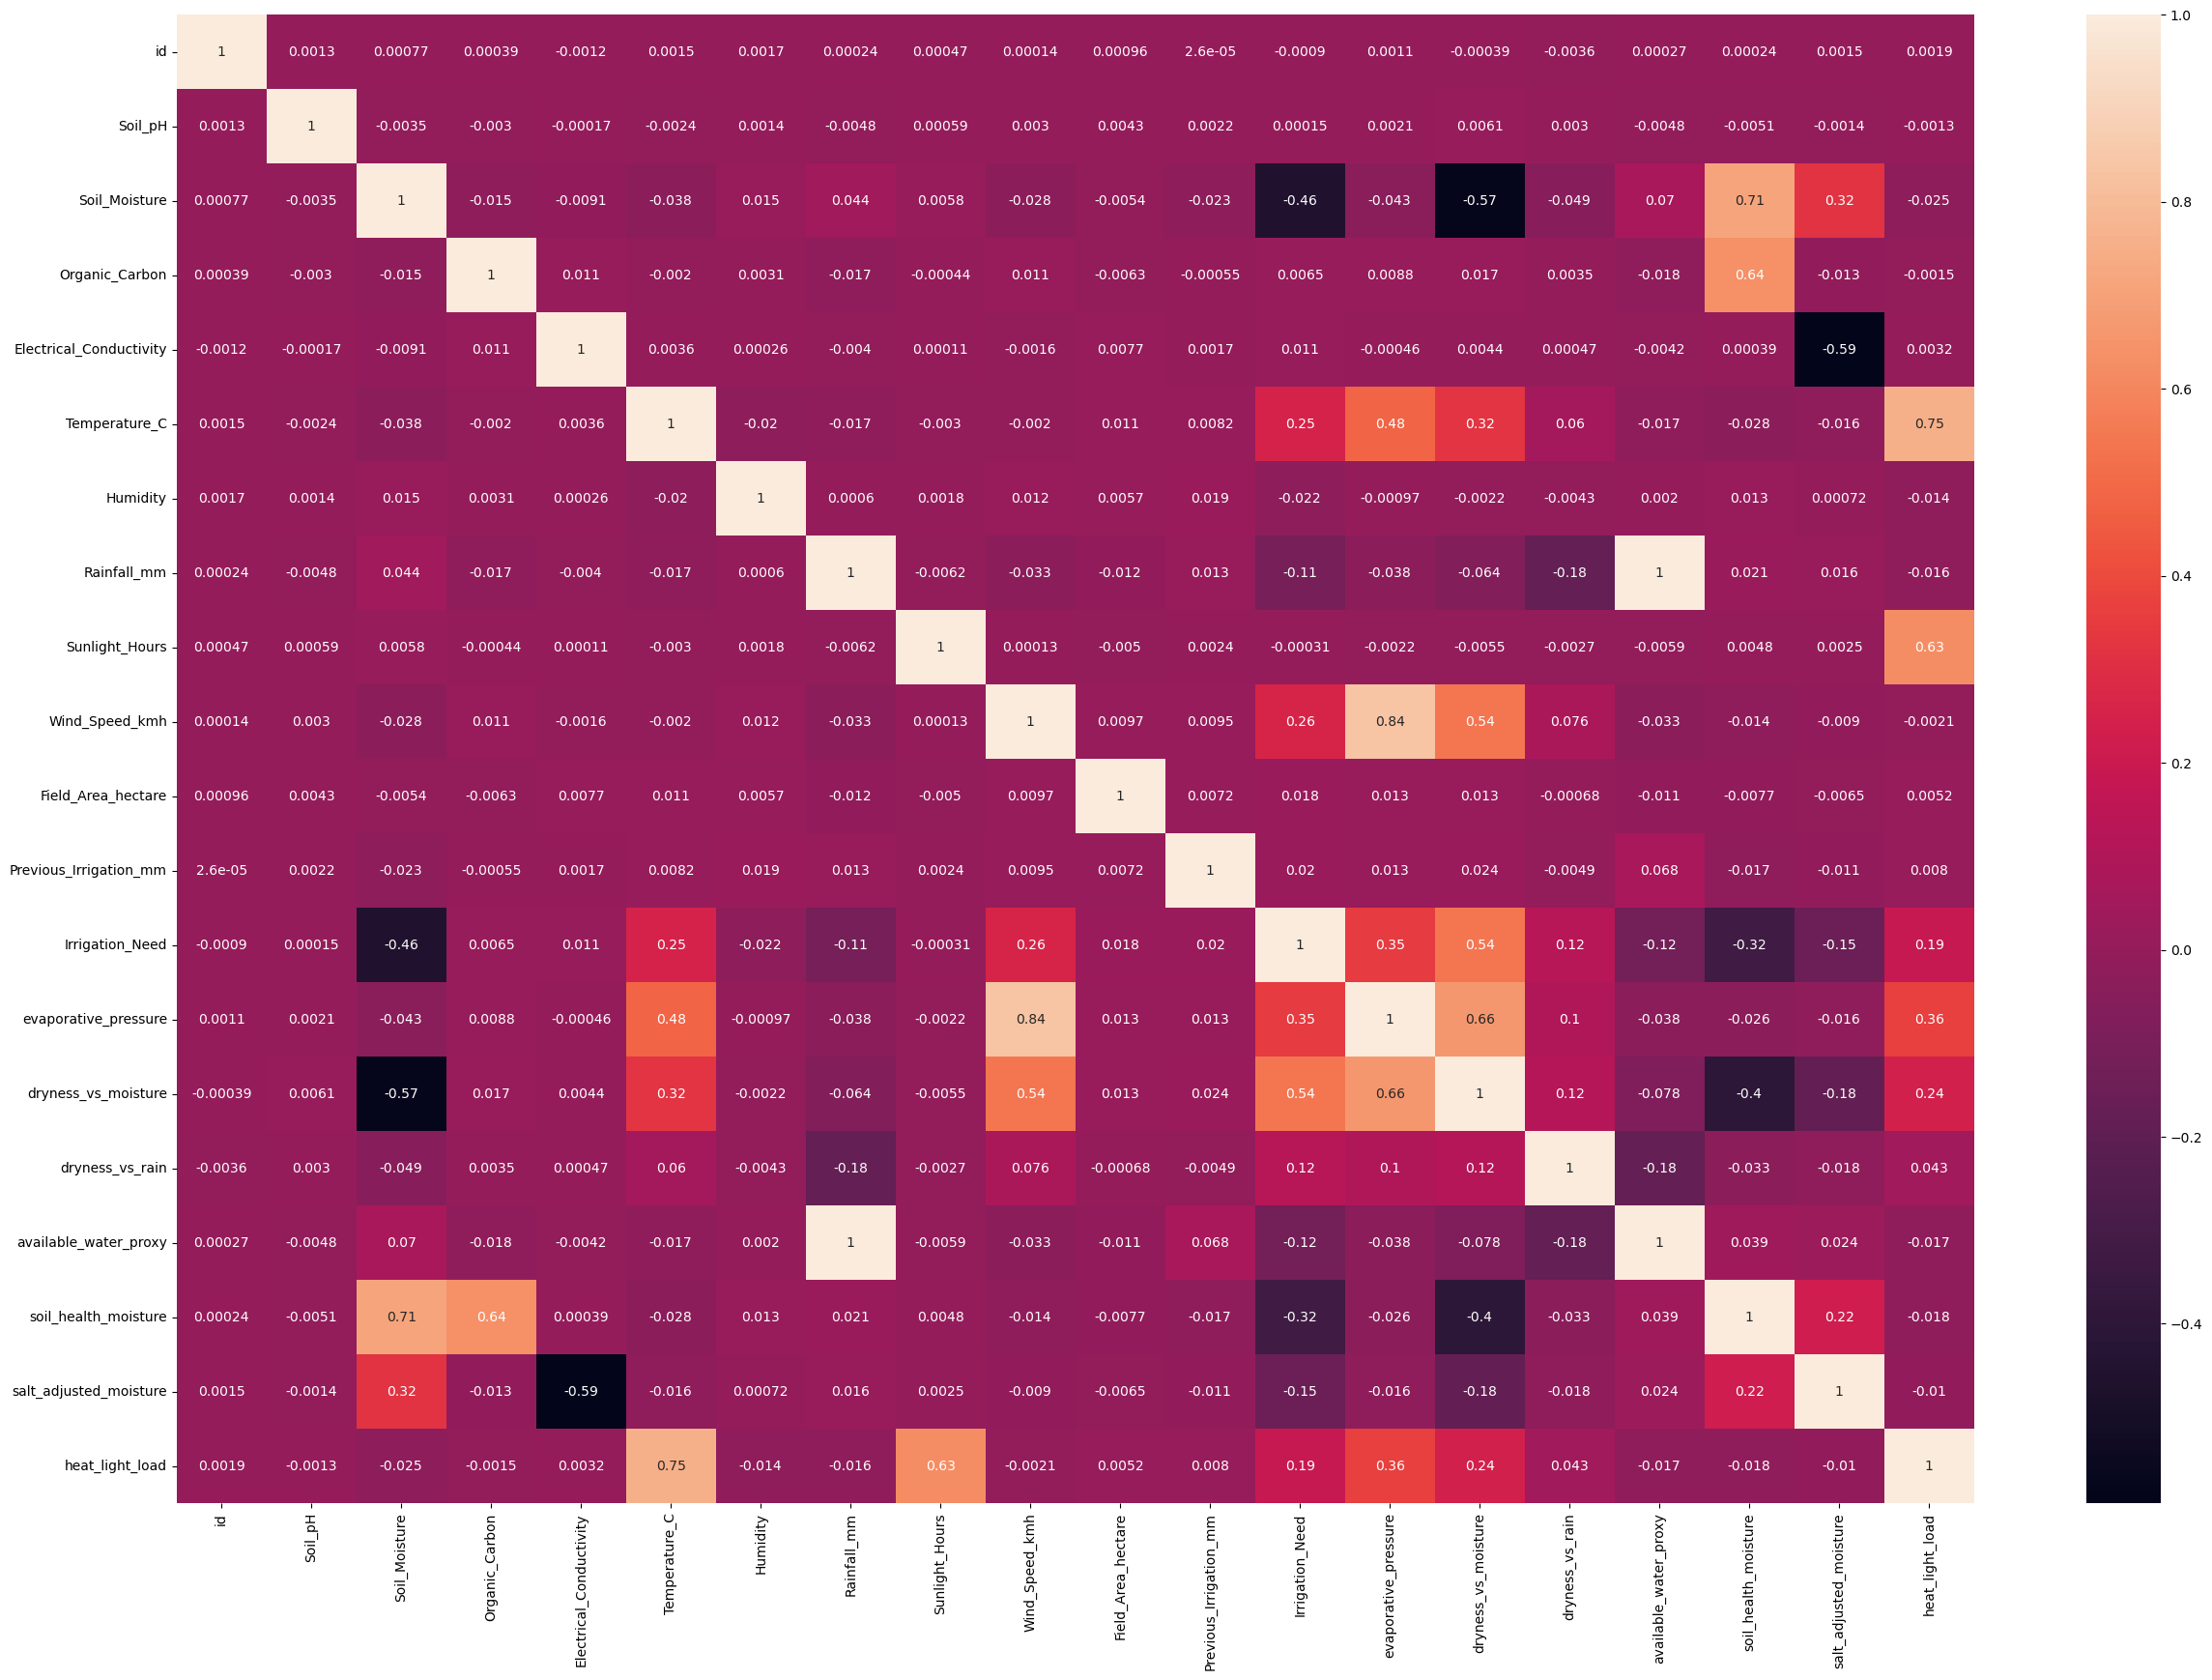

In [49]:
df.corr(numeric_only=True)
# heatmap corrolation
plt.figure(figsize=(30, 20)) # Create a figure with desired size
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [50]:
df.drop(['Soil_pH','Organic_Carbon','Sunlight_Hours'], axis=1, inplace=True) # drop low corrolation features
df_test.drop(['Soil_pH','Organic_Carbon','Sunlight_Hours'], axis=1, inplace=True) # drop low corrolation features in test data

In [51]:
# define x , y in train dataset
x = df.drop(['Irrigation_Need', 'id'], axis=1)
y = df['Irrigation_Need']
sub = df_test[['id']]
df_test = df_test.drop('id', axis=1)


## Encoding Categorical Features

In [ ]:
# identify numeric and categorical columns
numcol = x.select_dtypes(include=['int64', 'float64']).columns # numeric columns
numcol_test = df_test.select_dtypes(include=['int64', 'float64']).columns # numeric columns in test data
catcols = ['Crop_Type', 'Soil_Type', 'Crop_Growth_Stage', 'Season','Irrigation_Type','Water_Source','Region']

In [ ]:
# One-hot encoding for categorical features
oh = OneHotEncoder(sparse_output=False)
x_encoded = oh.fit_transform(x[catcols]) # one-hot encode the categorical features in the training data
x_encoded = pd.DataFrame(x_encoded, columns=oh.get_feature_names_out(catcols)) # put column names to the one-hot encoded features

df_test_encoded = oh.transform(df_test[catcols]) # one-hot encode the categorical features in the test data using the same encoder fitted on the test data data
df_test_encoded = pd.DataFrame(df_test_encoded, columns=oh.get_feature_names_out(catcols)) # put column names to the one-hot encoded features


In [55]:
df_test_encoded

,Crop_Type_Cotton,Crop_Type_Maize,Crop_Type_Potato,Crop_Type_Rice,Crop_Type_Sugarcane,Crop_Type_Wheat,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Sandy,Soil_Type_Silt,...,Irrigation_Type_Sprinkler,Water_Source_Groundwater,Water_Source_Rainwater,Water_Source_Reservoir,Water_Source_River,Region_Central,Region_East,Region_North,Region_South,Region_West
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269995,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
269996,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
269997,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
269998,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
# concat the one-hot encoded features with the rest of the features in x_train
x = pd.concat([x.drop(['Crop_Type', 'Soil_Type', 'Crop_Growth_Stage', 'Season','Irrigation_Type','Water_Source','Region'], axis=1).reset_index(drop=True), pd.DataFrame(x_encoded)], axis=1)

df_test =pd.concat([df_test.drop(['Crop_Type', 'Soil_Type', 'Crop_Growth_Stage', 'Season','Irrigation_Type','Water_Source','Region'], axis=1).reset_index(drop=True), pd.DataFrame(df_test_encoded)], axis=1)

In [57]:
# convert binary column in train and test data
mapping = {'No': 0, 'Yes': 1}
x['Mulching_Used'] = x['Mulching_Used'].map(mapping).astype(int)
#x_test['Mulching_Used'] = x_test['Mulching_Used'].map(mapping).astype(int)
df_test['Mulching_Used'] = df_test['Mulching_Used'].map(mapping).astype(int)

## Scaling Numerical Features

In [ ]:
scaler = StandardScaler() # initialize the StandardScaler
x[numcol] = scaler.fit_transform(x[numcol]) # fit the scaler on the training data and transform the training data

df_test[numcol_test] = scaler.transform(df_test[numcol_test]) # transform the df_test data using the fitted scaler

## Deep Learning libirary

In [60]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import L1, L2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import SGD, Adam

from kerastuner.tuners import RandomSearch

C:\Users\Admin\AppData\Local\Temp\ipykernel_7780\3935201726.py:7: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner.tuners import RandomSearch


## Deep Learning Model

In [61]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(x.shape[1],)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model.summary()

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,611 (80.51 KB)

 Trainable params: 20,611 (80.51 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:

early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
checkpoints = ModelCheckpoint("best_model.keras", 
                              monitor="val_accuracy", 
                              save_best_only=True)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(x,y, epochs=100,
          validation_split=0.1, batch_size=100, 
          callbacks=[early_stopping])

Epoch 1/100
5670/5670 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.8996 - loss: 0.2506 - val_accuracy: 0.9312 - val_loss: 0.1814
Epoch 2/100
5670/5670 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9425 - loss: 0.1546 - val_accuracy: 0.9516 - val_loss: 0.1394
Epoch 3/100
5670/5670 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9582 - loss: 0.1222 - val_accuracy: 0.9631 - val_loss: 0.1153
Epoch 4/100
5670/5670 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9671 - loss: 0.1040 - val_accuracy: 0.9681 - val_loss: 0.1015
Epoch 5/100
5670/5670 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9719 - loss: 0.0935 - val_accuracy: 0.9734 - val_loss: 0.0923
Epoch 6/100
5670/5670 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9749 - loss: 0.0869 - val_accuracy: 0.9747 - val_loss: 0.0874
Epoch 7/100
5670/5670 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9766 - loss: 0.0823 - val_accuracy: 0.9755 - val_loss: 0.0846
Epoch 8/100
5670/5670 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9780 - loss: 0

In [63]:
model.evaluate(x, y)

19688/19688 ━━━━━━━━━━━━━━━━━━━━ 16s 798us/step - accuracy: 0.9841 - loss: 0.0604


[0.06043737009167671, 0.9841238260269165]

In [64]:
model.predict(df_test)

8438/8438 ━━━━━━━━━━━━━━━━━━━━ 5s 613us/step


array([[9.9997377e-01, 2.6226457e-05, 1.5116641e-10],
       [9.3920046e-01, 6.0797911e-02, 1.5986867e-06],
       [9.9991369e-01, 8.6287168e-05, 6.1544041e-09],
       ...,
       [1.5122050e-05, 9.9960524e-01, 3.7963246e-04],
       [9.4960779e-01, 5.0385028e-02, 7.2814810e-06],
       [7.8211498e-01, 2.1772121e-01, 1.6384789e-04]], dtype=float32)

In [65]:
import pickle
with open('oh.pk1','wb')as f:
    with open('oh.pk1', 'wb') as f:
        pickle.dump(oh, f)

    with open('scaler.pk1', 'wb') as f:
        pickle.dump(scaler, f)

    model.save('best_model.keras')
    #model.save('model.h5')
#pickle.dumps(scaler,'encoder.pk1')
#pickle.dumps(scaler,'scaling.pk1')
model.save('best_model.keras')

model.save('model.h5')

In [66]:
y_pred = model.predict(df_test)
y_pred = y_pred.argmax(axis=1)
y_pred

8438/8438 ━━━━━━━━━━━━━━━━━━━━ 5s 609us/step


array([0, 0, 0, ..., 1, 0, 0])

In [69]:
sub['Irrigation_Need'] = y_pred
sub['Irrigation_Need'] = sub['Irrigation_Need'].map({0:"Low", 1:"Medium", 2:"High"})
sub

,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
...,...,...
269995,899995,Medium
269996,899996,Low
269997,899997,Medium
269998,899998,Low


In [70]:
sub.to_csv("sub4.csv", index=False)